In [ ]:
import torch
import torchaudio
import kagglehub
from IPython.display import Audio, display
import matplotlib.pyplot as plt
from pathlib import Path

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

c:\Users\david\miniconda3\envs\torch_sm120\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 5070


## Dataset creation

In [2]:
# Download the dataset
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")+'/Data/genres_original' 
# which is from https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification (YOU DONT NEED TO DOWNLOAD IT FROM HERE)

# Figure out file locations
dataset_dir = Path(path)
all_files = list(dataset_dir.glob("*/*.wav")) 
# all_files = [str(f.relative_to(dataset_dir)) for f in all_files]

torchaudio.load(all_files[0])

ImportError: TorchCodec is required for load_with_torchcodec. Please install torchcodec to use this function.

In [ ]:


# Create dataset
dataset = tf.data.Dataset.from_tensor_slices(all_files) # enable streaming

dataset_dir = str(dataset_dir)
def load_audio(file_path):
    # audio_tensor = tfio.audio.AudioIOTensor(file_path) # AAAAAAAAAAAAAAAAAAAAAFHDSLAFHUSDAGFIOSDBAYF
    # Read the file
    audio_binary = tf.io.read_file(tf.strings.join([dataset_dir, "/", file_path]))
    # Decode WAV (gives waveform tensor and sample rate)
    waveform, sample_rate = tf.audio.decode_wav(audio_binary) 
    waveform = tf.squeeze(waveform, axis=-1)[:SAMPLE_RATE*DURATION] # this is exactly 10 seconds, samples arent exactly the same size
    return file_path, waveform, sample_rate  # return path, waveform and sample rate

dataset = dataset.map(load_audio, num_parallel_calls=tf.data.AUTOTUNE) # not actual autotune, tf tunes the number of threads. remember that map is a lazy process

100%|██████████| 1.21G/1.21G [00:31<00:00, 41.8MB/s]

Extracting files...


(<tf.Tensor: shape=(), dtype=string, numpy=b'blues\\blues.00000.wav'>, <tf.Tensor: shape=(220500,), dtype=float32, numpy=
array([0.00732422, 0.01660156, 0.00762939, ..., 0.07623291, 0.07675171,
       0.08129883], dtype=float32)>, <tf.Tensor: shape=(), dtype=int32, numpy=22050>)


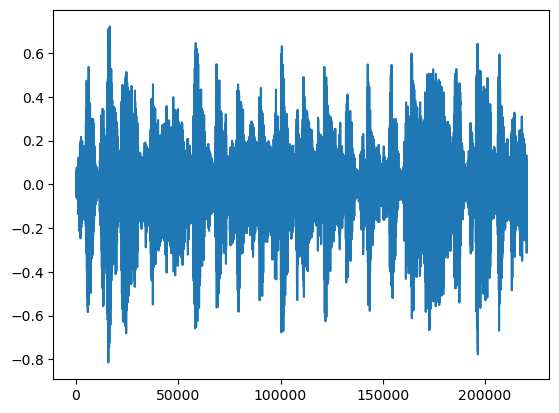

In [4]:
# Trying out the dataset

def noisify(audio, maxval=0.2):
    return (audio + tf.random.uniform(audio.shape, minval=-maxval, maxval=maxval)) / 2.0

for tensor in dataset.take(1):
    # look at the tensor. look at it.
    print(tensor)
    audio = tensor[1].numpy()
    rate = tensor[2].numpy()

    # plot waveform
    plt.figure()
    plt.plot(audio)
    plt.show()

    # listen to  r e g g a e, relaaaax, rest your eyes, drink some water
    display(Audio(audio, rate=rate))

    # You must suffer like I have.
    display(Audio(noisify(audio), rate=rate))

In [5]:
# noisify a batch

# take a batch and try it out
batch_size = 4
batched_dataset = dataset.batch(batch_size)

for batch in batched_dataset.take(1):
    filenames, waveforms, sample_rates = batch
    noisy_waveforms = noisify(waveforms)
    loss = tf.reduce_mean(tf.square(waveforms -  noisy_waveforms))
    print(loss)

tf.Tensor(0.008749519, shape=(), dtype=float32)


## Basic autoencoder


In [2]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
tf.debugging.set_log_device_placement(True)
print(tf.config.list_physical_devices('GPU'))

[]


In [3]:
print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.1
GPUs detected: []
